<a href="https://colab.research.google.com/github/JSheleg/ut_austin_aiml_cert/blob/main/Sheleg_NLP_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

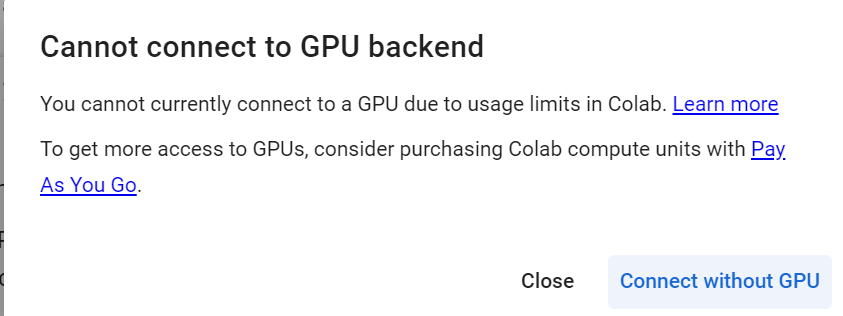

## **Installing and Importing Necessary Libraries**

In [ ]:
# # downgrade numba to prevent package conflict
# !pip install numba==0.60.0


In [ ]:
# check current versions:
import numpy, pandas, tensorflow, numba
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("tensorflow:", tensorflow.__version__)
print("numba:", numba.__version__)


numpy: 1.26.4
pandas: 2.2.2
tensorflow: 2.18.0
numba: 0.60.0


In [ ]:
# installing the libraries for transformers
!pip install -U sentence-transformers==4.0.2 gensim==4.3.3 transformers==4.50.3 tqdm==4.67.1 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 pandas==2.2.2 numpy==1.26.4 -q


In [ ]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming


# to create Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

# To build, tune, and evaluate ML models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Loading the dataset**

In [ ]:
# uncomment and run the following code if Google Colab is being used and the dataset is in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
stock_news = pd.read_csv("/content/drive/MyDrive/UT_Austin_ML/natural_language_processing/project_stockmarket_sentiment_analysis/stock_news.csv")

In [ ]:
# copy of data
data = stock_news.copy()

## **Data Overview**

In [ ]:
# view top 5
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


In [ ]:
# view last 5
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influenc...",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks u...",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,This article reports that the S&P 500 reached...,50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,The Federal Reserve is anticipated to keep in...,50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung E...",50.764999,50.849998,49.7775,48.70879,186139600,0


In [ ]:
# view shape
data.shape

(349, 8)

In [ ]:
# summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:
data.Date[0]

'2019-01-02'

In [ ]:
data.News[0]

" The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January."

There are 8 columns with 349 rows of data.
* `Date` is listed currently as an object, but should be a datetime format
* There is currently no missing data according to the info.

In [ ]:
# convert date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


In [ ]:
data.Date[0]

Timestamp('2019-01-02 00:00:00')

In [ ]:
# view stats
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,349,2019-02-16 16:05:30.085959936,2019-01-02 00:00:00,2019-01-14 00:00:00,2019-02-05 00:00:00,2019-03-22 00:00:00,2019-04-30 00:00:00,NaN
Open,349.0,46.229233,37.567501,41.740002,45.974998,50.7075,66.817497,6.442817
High,349.0,46.700458,37.817501,42.244999,46.025002,50.849998,67.0625,6.507321
Low,349.0,45.745394,37.305,41.482498,45.639999,49.7775,65.862503,6.391976
Close,349.0,44.926317,36.254131,40.246914,44.596924,49.11079,64.805229,6.398338
Volume,349.0,128948236.103152,45448000.0,103272000.0,115627200.0,151125200.0,244439200.0,43170314.918964
Label,349.0,-0.054441,-1.0,-1.0,0.0,0.0,1.0,0.715119


* `Date` ranges from 2019-01-02 to 2019-04-03 which is 3 months of data
* `Open` which indicates the stock price in dollars at the beginning of the day has a min of 37.6 and a max of 66.8. Mean is 46.2 while 50% quartile is 46 which is relatively close
* `High` is the highest stock price of the day. It has a min of 37.81 and a max of 67 with a mean of 46.7 and 50% quartile of 46.02.
* `Low` is the lowest stock price of the day. It has a min of 37.305 and a max of 65.86 with a mean of 45.75 and a 50% quartile of 45.6.
* `Close` is the adjusted stock price in dollars at the end of the day. Min is 36.25, max is 64.81 with mean at 44.9 and 50% at 44.5
* `Volume` is the number of shares traded. Min is 4,5448,000 and Max is 244,439,200.
* `Label` shows the polarity of the news content. It is currently an int but might be better as a categorical variable. The values are either
  * 1: positive
  * 0: neutral
  * -1: negative
  * This will be our target variable that we will be looking to predict


In [ ]:
# check for duplicates
print("There are", data.duplicated().sum(), "duplicated values in the dataset")

There are 0 duplicated values in the dataset


In [ ]:
# check for missing values:
print("There are", data.isnull().sum().sum(), " missing values in the dataset")

There are 0  missing values in the dataset


## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

####`Label`

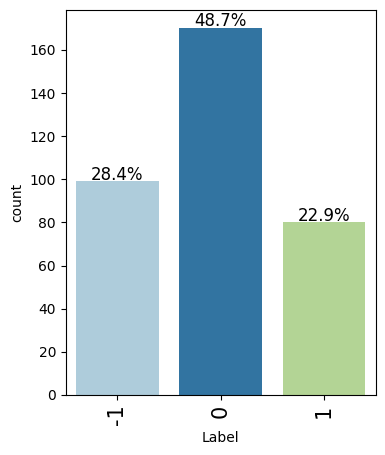

In [ ]:
labeled_barplot(data, 'Label', perc=True)

* Just under half of the reviews are neutral (48.7%) while negative reviews make up 28.4% of the reviews and positive reviews make up 22.9% of the reviews

#### `Price`

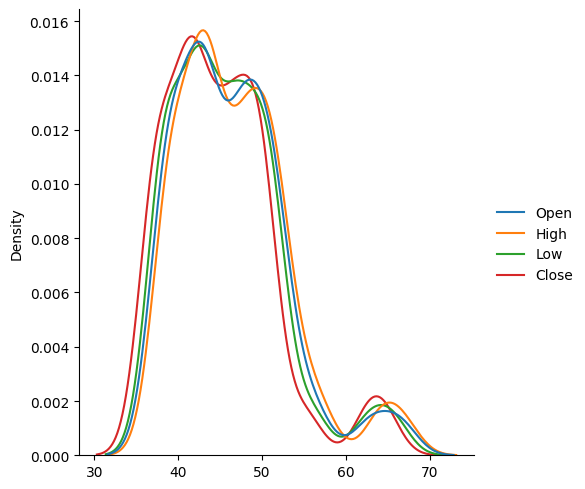

In [ ]:
sns.displot(data=data[["Open","High","Low","Close"]], kind="kde", palette="tab10")

* The prices which include `Open`, `High`, `Low`, `Close` all seem to be relatively grouped together.

#### `Volume`

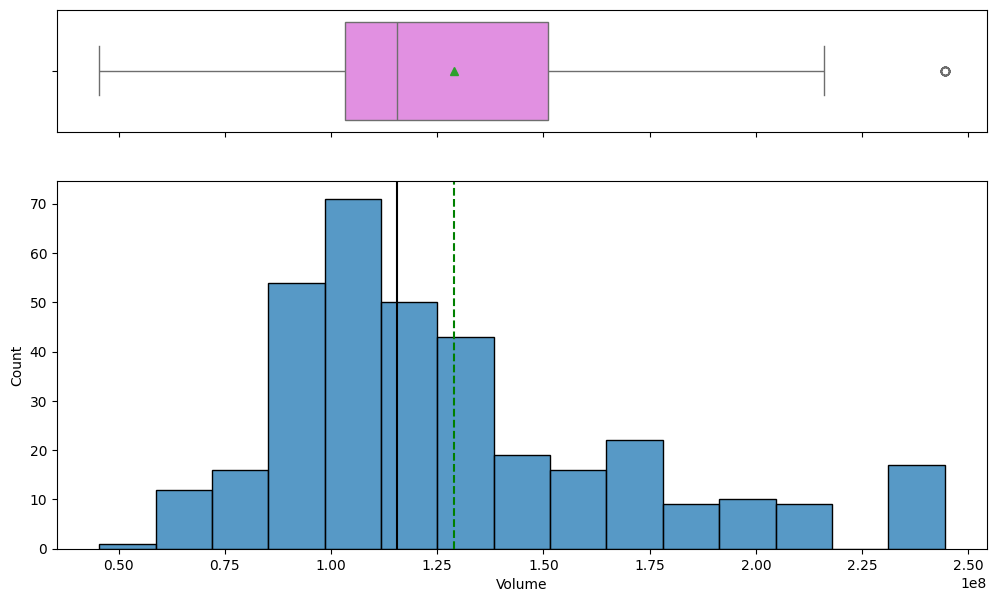

In [ ]:
histogram_boxplot(data, 'Volume')

* `Volume` seems to be skewed to the right with an outlier on the right side.
* 75% of the volume is 1.5e8  or 151,125,200

#### `News`

In [ ]:
#Calculating the total number of words present in the news content.
data['news_len'] = data['News'].apply(lambda x: len(x.split(' ')))
data['news_len'].describe()

,news_len
count,349.000000
mean,49.312321
std,5.727770
min,19.000000
25%,46.000000
50%,50.000000
75%,53.000000
max,61.000000


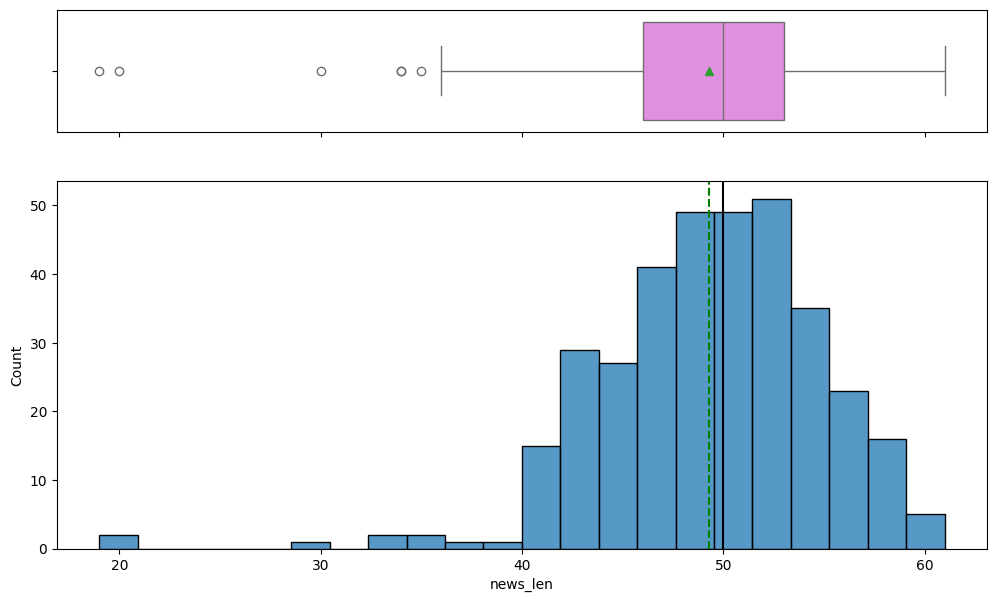

In [ ]:
histogram_boxplot(data, 'news_len')


* The smallest article of `News` has 19 words while the largest article has 61 words.
* The average `News` article length is 49.3 words while the 50% is 50 words
* The `News` article length is skewed to the left with multiple outliers on the lower end of the article length.
* The largest concentration of words is about 52 words.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

In [ ]:
cols_list =data.columns.tolist()
cols_list

['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label', 'news_len']

<Axes: >

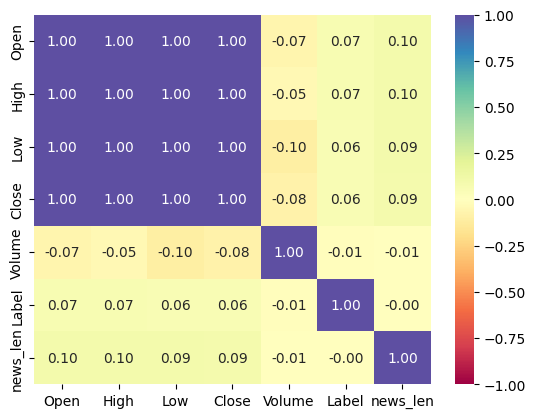

In [ ]:
sns.heatmap(
    data[cols_list].corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)

* Open, High, Low and Close seem to be completely correlated with each other.
* There seems to be no strong correlation between any of the other variables

#### `Price ( Open, High, Low, Close) `

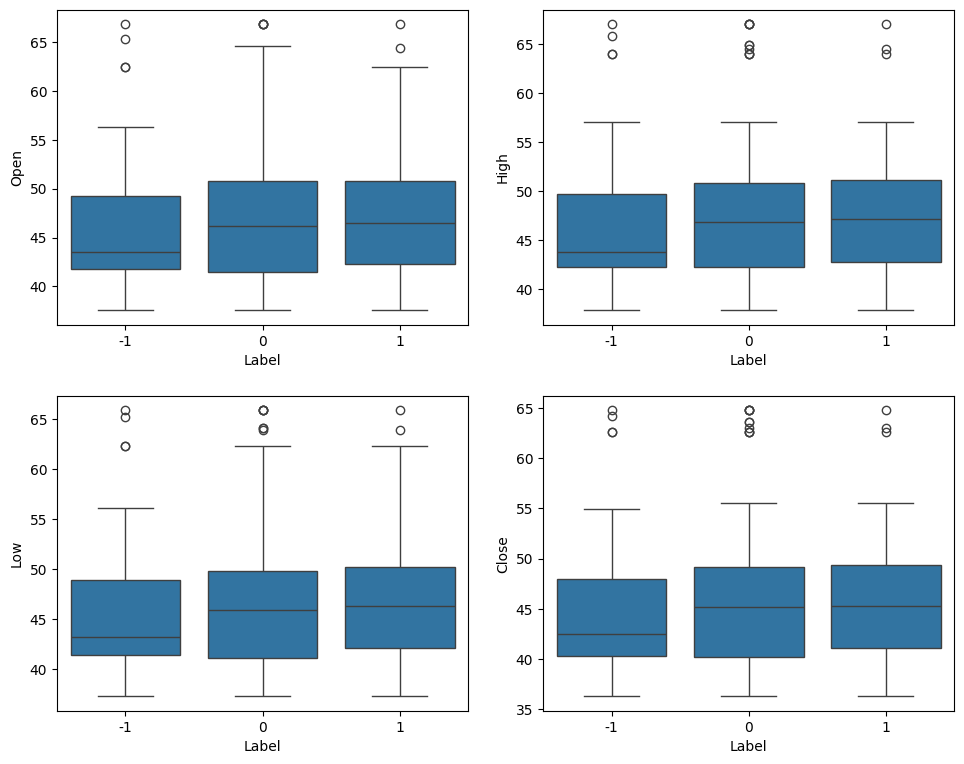

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=data, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

* There seems to be outliers for all Labels (-1, 0, 1) across all Prices ( Open, High, Low, Close)

#### `Date vs Price`

In [ ]:
stock_daily = data.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,41.740002,42.244999,41.482498,40.246914,130672400.0
2019-01-03,43.570000,43.787498,43.222500,42.470604,103544800.0
2019-01-04,47.910000,47.919998,47.095001,46.419842,111448000.0
2019-01-07,50.792500,51.122501,50.162498,49.110790,109012000.0
2019-01-08,53.474998,54.507500,51.685001,50.787209,216071600.0


In [ ]:
stock_daily.shape

(71, 5)

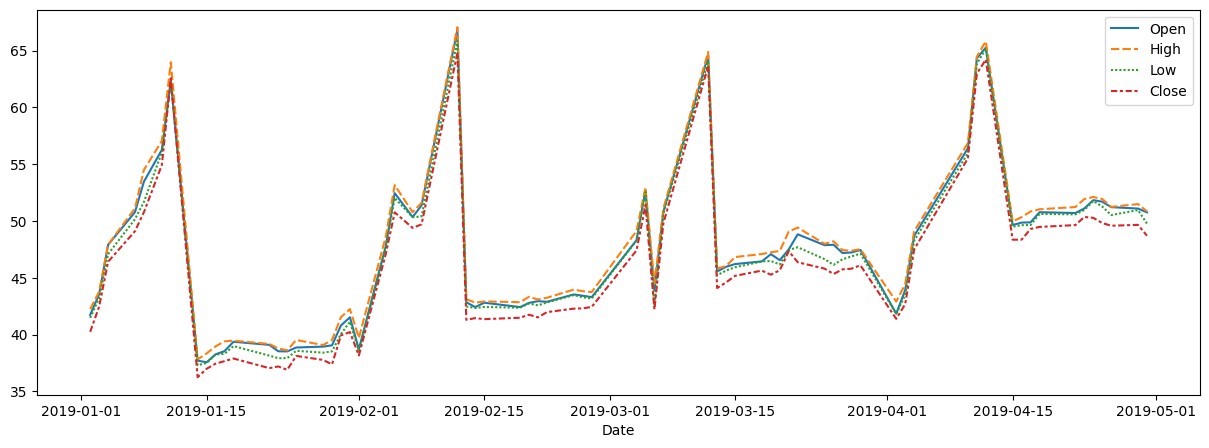

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop("Volume", axis=1));

* As seen in the correlation matrix, when grouped by Date, Open,High, Low and Close closely follow each other with only small variations in Volume being seen in times of lower volume months.
* Peak volumes seem to be around 60-65


#### `Volume vs Close Price`



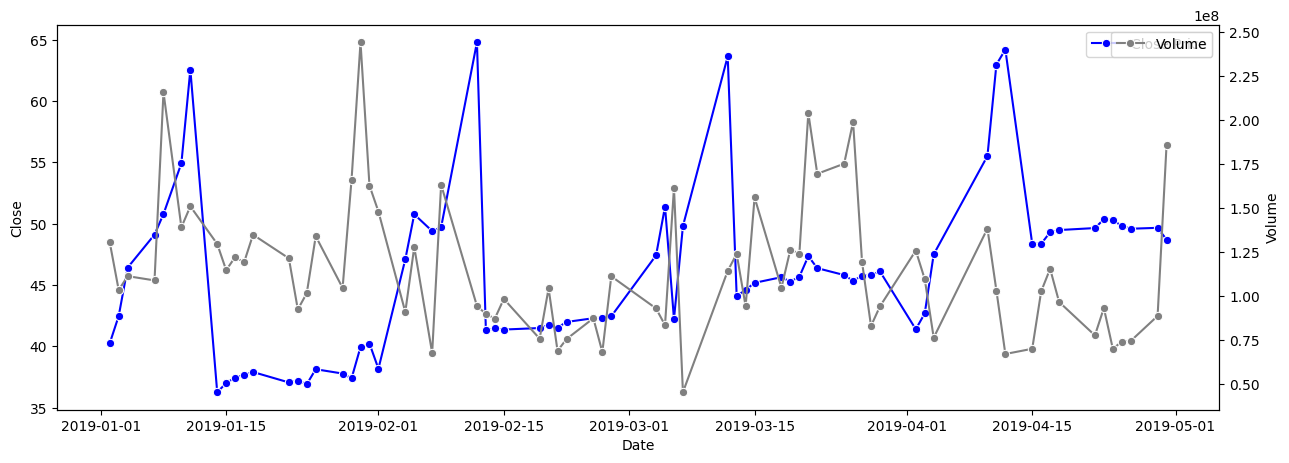

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

* It seems that when volume is lower as in the number of shares traded, the Close price is higher. This would indicate that people are holding on to their shares
* Then it seems the market corrects with more people selling their shares (increasing the volume) driving the close price down as it reduces the price of the shares

#### `Volume vs High Price`


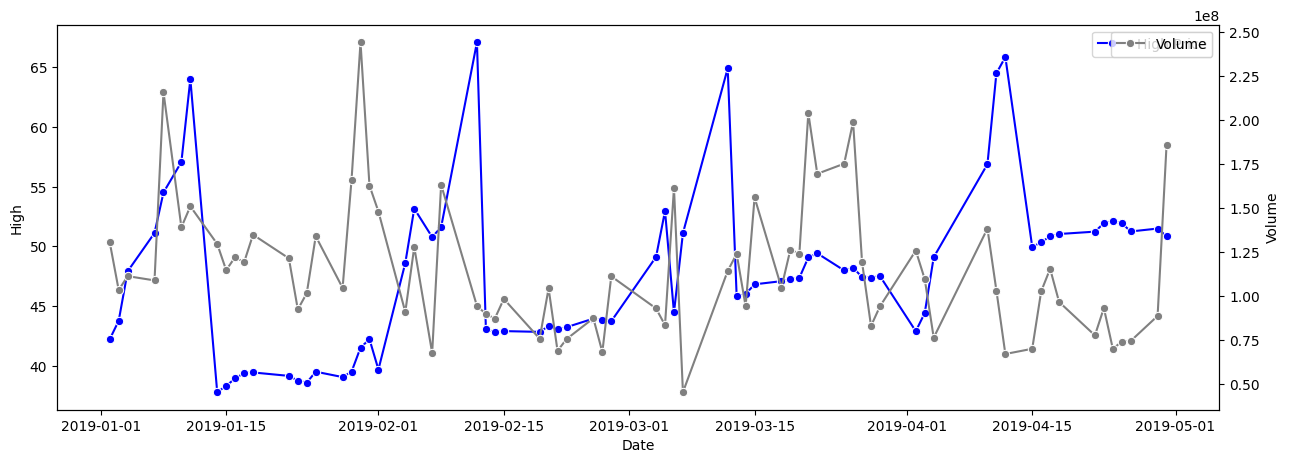

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='High', ax=ax1, color='blue', marker='o', label='High Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

* Follows a very similar trend to the Volume vs Close Price

In [ ]:
data.head()


,Date,News,Open,High,Low,Close,Volume,Label,news_len
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,46
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,51
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,49
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,51
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50


#### `Label vs Price`

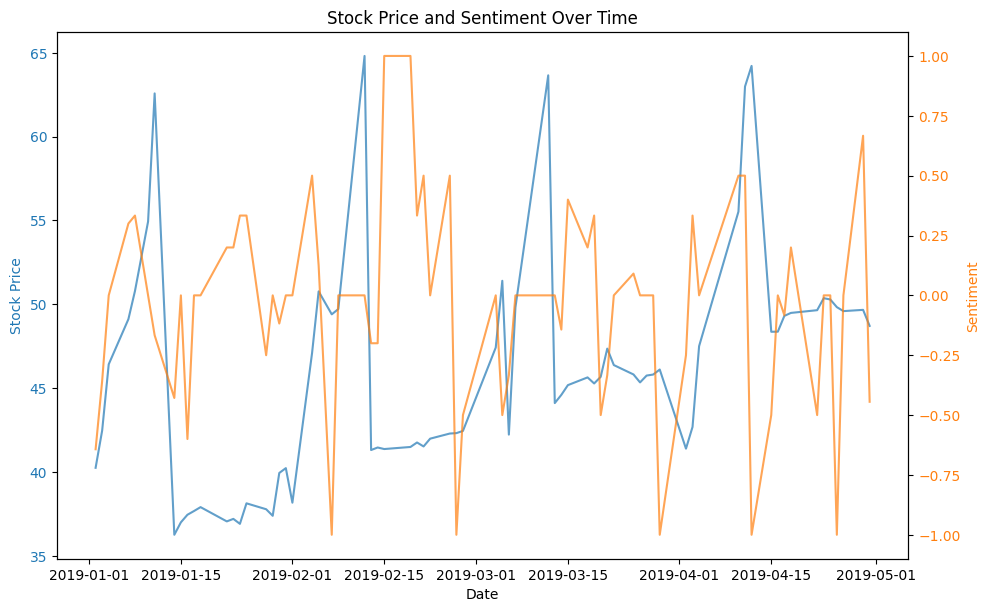

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data_analysis = data.copy()
# Calculate average daily sentiment (mean of 'Label')
data_analysis['Sentiment'] = data_analysis.groupby(data_analysis['Date'])['Label'].transform('mean')

# Plot sentiment and stock prices
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot stock price
ax1.plot(data_analysis['Date'], data_analysis['Close'], color='tab:blue', label='Stock Price (Close)', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for sentiment
ax2 = ax1.twinx()
ax2.plot(data_analysis['Date'], data_analysis['Sentiment'], color='tab:orange', label='Sentiment', alpha=0.7)
ax2.set_ylabel('Sentiment', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
plt.title('Stock Price and Sentiment Over Time')
plt.show()

* It seems like Sentiment is more positive when stock prices are lower and when sentiment starts to decrease, stock price goes up. Not sure what that truly means, but it is certainly interesting!

## **Data Preprocessing**

In [ ]:
# Stat summary of Date
data["Date"].describe()

,Date
count,349
mean,2019-02-16 16:05:30.085959936
min,2019-01-02 00:00:00
25%,2019-01-14 00:00:00
50%,2019-02-05 00:00:00
75%,2019-03-22 00:00:00
max,2019-04-30 00:00:00


In [ ]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,news_len
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,46
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,51
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,49
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,51
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50


In [ ]:
# Dropped Highly Correlated Columns - Open, High, Low and Close are highly correlated (1.00). Based on external knowledge, it seems Close is the most important
data = data[['Date', 'News', 'Close', 'Volume', 'Label', 'news_len']]

In [ ]:
data.head()

,Date,News,Close,Volume,Label,news_len
0,2019-01-02,The tech sector experienced a significant dec...,40.246914,130672400,-1,46
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,40.246914,130672400,-1,51
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,40.246914,130672400,-1,49
3,2019-01-02,This news article reports that yields on long...,40.246914,130672400,-1,51
4,2019-01-02,Apple's revenue warning led to a decline in U...,40.246914,130672400,-1,50


In [ ]:
# Lets see if splitting up the Date into smaller chunks might help
data['day_of_the_week'] = data['Date'].dt.dayofweek
data['month'] = data['Date'].dt.month
data['week_of_year'] = data['Date'].dt.isocalendar().week

In [ ]:
data.head()

,Date,News,Close,Volume,Label,news_len,day_of_the_week,month,week_of_year
0,2019-01-02,The tech sector experienced a significant dec...,40.246914,130672400,-1,46,2,1,1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,40.246914,130672400,-1,51,2,1,1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,40.246914,130672400,-1,49,2,1,1
3,2019-01-02,This news article reports that yields on long...,40.246914,130672400,-1,51,2,1,1
4,2019-01-02,Apple's revenue warning led to a decline in U...,40.246914,130672400,-1,50,2,1,1


In [ ]:
# Log Transform Skewed Features - log transformation to help stabilize variance
data['log_volume'] = np.log1p(data['Volume'])  # log(Volume + 1) to avoid log(0)
data.drop('Volume', axis=1, inplace=True)

In [ ]:
data.head()

,Date,News,Close,Label,news_len,day_of_the_week,month,week_of_year,log_volume
0,2019-01-02,The tech sector experienced a significant dec...,40.246914,-1,46,2,1,1,18.688204
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,40.246914,-1,51,2,1,1,18.688204
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,40.246914,-1,49,2,1,1,18.688204
3,2019-01-02,This news article reports that yields on long...,40.246914,-1,51,2,1,1,18.688204
4,2019-01-02,Apple's revenue warning led to a decline in U...,40.246914,-1,50,2,1,1,18.688204


In [ ]:
data['Label'].value_counts()

,count
Label,
0,170
-1,99
1,80


* Label is imbalanced, will need to handle in the models class_weight parameter

### Train-Test-Validation Split

In [ ]:
# splitting data into proper training, validation and test sets
# drop target variable and Date as Date has been seperated into day of the week, month and week of the year

X = data.drop(['Label', 'Date'], axis=1)

# create target feature
y = data['Label']

In [ ]:
X.head()

,News,Close,news_len,day_of_the_week,month,week_of_year,log_volume
0,The tech sector experienced a significant dec...,40.246914,46,2,1,1,18.688204
1,Apple lowered its fiscal Q1 revenue guidance ...,40.246914,51,2,1,1,18.688204
2,Apple cut its fiscal first quarter revenue fo...,40.246914,49,2,1,1,18.688204
3,This news article reports that yields on long...,40.246914,51,2,1,1,18.688204
4,Apple's revenue warning led to a decline in U...,40.246914,50,2,1,1,18.688204


In [ ]:
y.head()

,Label
0,-1
1,-1
2,-1
3,-1
4,-1


In [ ]:
# split data into training, validation and test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split( X_temp, y_temp, test_size=0.2, random_state=1, stratify=y_temp)

print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (223, 7)
Validation data shape (56, 7)
Test data shape  (70, 7)
Train label shape (223,)
Validation label shape (56,)
Test label shape  (70,)


### Preprocessing the textual column

In [ ]:
X_train.head()

,News,Close,news_len,day_of_the_week,month,week_of_year,log_volume
84,The weak Chinese trade data led to a halt in ...,36.254131,45,0,1,3,18.681172
307,"In a complex trial in San Diego, Apple accuse...",48.364113,54,1,4,16,18.448156
10,The Australian dollar experienced significant...,40.246914,43,2,1,1,18.688204
291,"The S&P 500, Dow Jones Industrial Average, an...",42.684212,44,2,4,14,18.513668
313,The Chinese government is considering draftin...,49.305897,50,2,4,16,18.565882


In [ ]:
# # Loading the Porter Stemmer
# ps = PorterStemmer()

In [ ]:
import re
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Keep only letters, numbers, spaces, and common punctuation (like '&', '500')
    text = re.sub(r'[^a-zA-Z0-9\s&.,-]', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    text = ' '.join([word for word in words if word not in stopwords.words('english')])

    # # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    # text = ' '.join([ps.stem(word) for word in words])


    # From reading about Word2Vec and GloVe, porter stemming might cause a loss in important nuances.

    return text

In [ ]:
# preprocessing the textual column
X_train['News_Cleaned'] = X_train['News'].apply(preprocess_text)
X_val['News_Cleaned'] = X_val['News'].apply(preprocess_text)
X_test['News_Cleaned'] = X_test['News'].apply(preprocess_text)

In [ ]:
X_train.head()

,News,Close,news_len,day_of_the_week,month,week_of_year,log_volume,News_Cleaned
84,The weak Chinese trade data led to a halt in ...,36.254131,45,0,1,3,18.681172,weak chinese trade data led halt europes four-...
307,"In a complex trial in San Diego, Apple accuse...",48.364113,54,1,4,16,18.448156,"complex trial san diego, apple accused qualcom..."
10,The Australian dollar experienced significant...,40.246914,43,2,1,1,18.688204,australian dollar experienced significant vola...
291,"The S&P 500, Dow Jones Industrial Average, an...",42.684212,44,2,4,14,18.513668,"s&p 500, dow jones industrial average, nasdaq ..."
313,The Chinese government is considering draftin...,49.305897,50,2,4,16,18.565882,chinese government considering drafting stimul...


## **Word Embeddings**

### Word2Vec

In [ ]:
# performing word embedding on the News_Cleaned that was preprocessed

# Creating a list of all words in our data
words_list = [item.split(" ") for item in X_train['News_Cleaned'].values]

# Train Word2Vec model on `X_train` data only
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 3, window=5, workers = 6)

# Checking the size of the vocabulary
print("Length of the vocabulary is", len(model_W2V.wv))

Length of the vocabulary is 645


In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([ 2.7953749e-04,  3.8542186e-03,  3.0383535e-03,  3.6838355e-03,
       -2.7422304e-03, -1.4357120e-04, -7.1262964e-04,  4.1448595e-03,
        1.0461851e-03,  1.3198148e-03,  2.0436225e-03, -4.8811774e-04,
        3.5375550e-03, -9.9561037e-04, -3.5022753e-03, -3.2714477e-03,
        2.9865555e-03, -1.5433695e-03, -5.2115767e-05,  1.4583996e-03,
       -1.9706686e-03, -2.1413339e-03,  6.0619693e-04,  4.8377749e-04,
        2.6789554e-03,  2.1843794e-03, -4.7945753e-03,  6.8891578e-04,
        9.3646959e-04, -1.2158072e-03,  2.6827299e-03, -3.0722069e-03,
        2.6954981e-03, -2.5803705e-03,  1.1353977e-03, -2.1573475e-03,
       -1.2301517e-03, -5.2335863e-03, -7.8082719e-04, -1.0823061e-03,
       -2.6744187e-03,  7.9137436e-04,  6.6200586e-04, -1.4723064e-03,
       -1.3377557e-03, -1.1169030e-03,  1.1659806e-03, -9.5887843e-04,
       -3.5885302e-03,  9.1275788e-04,  3.3288347e-03,  3.2862020e-03,
       -4.2905072e-03,  1.6583081e-03, -3.1342132e-03, -1.0647558e-03,
      

In [ ]:
# # Retrieving the words present in the Word2Vec model's vocabulary
# words = list(model_W2V.wv.key_to_index.keys())

# # Retrieving word vectors for all the words present in the model's vocabulary
# wvs = model_W2V.wv[words].tolist()

# # Creating a dictionary of words and their corresponding vectors
# word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in model_W2V.wv]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += model_W2V.wv[word]

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News_Cleaned"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News_Cleaned"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News_Cleaned"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.05207228660583496


In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(223, 300) (56, 300) (70, 300)


In [ ]:
X_train_wv.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,1.072940e-07,0.001326,-0.001332,0.000899,-0.000412,-0.002299,0.001186,0.003615,6.395225e-04,-0.000840,...,-0.000336,0.002233,0.000887,-0.000238,0.002132,0.002608,-0.000787,-0.000270,0.000338,-0.000118
1,2.458334e-04,0.001097,0.000260,0.000293,-0.001110,-0.002212,0.001456,0.003473,6.846600e-04,-0.001237,...,-0.001125,0.001909,0.001968,0.000017,0.002365,0.003148,0.000792,-0.001328,0.001377,-0.000955
2,-1.114777e-03,0.001006,0.000065,0.000434,0.000694,-0.001383,0.001194,0.003123,1.935957e-03,-0.000593,...,0.000487,0.002001,0.000684,-0.001464,0.002156,0.001354,-0.001369,-0.000968,0.000963,0.000293
3,-3.336050e-04,0.001245,-0.000449,0.000414,-0.000112,-0.001111,0.000961,0.003245,5.324333e-04,-0.000819,...,-0.000102,0.001272,0.000468,-0.000307,0.001294,0.001792,-0.000403,-0.001094,0.000905,0.000168
4,2.610583e-04,0.000562,-0.000184,0.000536,0.000080,-0.001411,0.000673,0.003363,3.134866e-07,-0.000725,...,-0.000725,0.000992,0.000849,-0.000107,0.001617,0.000806,-0.000229,-0.000921,0.000701,-0.000016


### GloVe

In [ ]:
glove_input_file = '/content/drive/MyDrive/UT_Austin_ML/natural_language_processing/project_stockmarket_sentiment_analysis/glove.6B.100d.txt (1).word2vec'

In [ ]:
# load the Stanford GloVe model
filename = glove_input_file
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


In [ ]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [ ]:
# # Retrieving the words present in the GloVe model's vocabulary
# glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_word_vector_dict]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += glove_word_vector_dict[word]

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News_Cleaned"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_gl = pd.DataFrame(X_val["News_Cleaned"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_gl = pd.DataFrame(X_test["News_Cleaned"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.0269162654876709


In [ ]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape)

(223, 100) (56, 100) (70, 100)


### Sentence Transformer

#### Defining the model

In [ ]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Encoding the dataset

In [ ]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ensure model is on the correct device (GPU/CPU)
model.to(device)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
# encoding the dataset
start = time.time()

X_train_st = model.encode(X_train["News_Cleaned"].values, show_progress_bar=True, device=device)
X_val_st = model.encode(X_val["News_Cleaned"].values, show_progress_bar=True, device=device)
X_test_st = model.encode(X_test["News_Cleaned"].values, show_progress_bar=True, device=device)

end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Time taken  1.0157485008239746


In [ ]:
print(X_train_st.shape, X_val_st.shape, X_test_st.shape)

(223, 384) (56, 384) (70, 384)


* Each news content has been converted to a 384-dimensional vector

## **Sentiment Analysis**

### Model Evalution Criterion

The goal of evaluationg a classification model in this scenario is to ensure that the model accurately identifies positive sentiment in news articles, as this sentiment is directly tied to stock market movement.

Focus should be on minimizing false negatives (FN) since failing to identify a poistive sentiment could lead to missed investment opportunties.


Which metric to optimize?

It is important to chose a metric that will ensure the maximum number of positive sentiments (TP) are predicted by the model. In other words, we need to minimize false negatives. This is done by using Recall as our primary metrics. A high recall means we captured a large portion of the positive sentiments and minimizing the number of false negatives (FN).



* True Positives (TP): Correctly predicted positive sentiment - means postive gain in stock market

* False Negatives (FN): Positive sentiment that was incorrectly predicted as negative or neutral - means a loss of opportunity

* False Positives (FP): Negative or neutral sentiment incorrectly predicted as positive - means a chance of a loss for investors which is bad for business

* True Negatives (TN): Correctly predicted negative or neutral sentiment. - means there was no loss of opportunity and no poor decisions

### Utility Functions

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Base Model - Word2Vec

In [ ]:
#handle class imbalance

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

# base_wv = GradientBoostingClassifier(random_state = 42)
base_wv = RandomForestClassifier(random_state=42, class_weight='balanced')
# base_wv = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Fitting on train data
# base_wv.fit(X_train_wv, y_train, sample_weight =sample_weights) # for GradientBoosting
base_wv.fit(X_train_wv, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

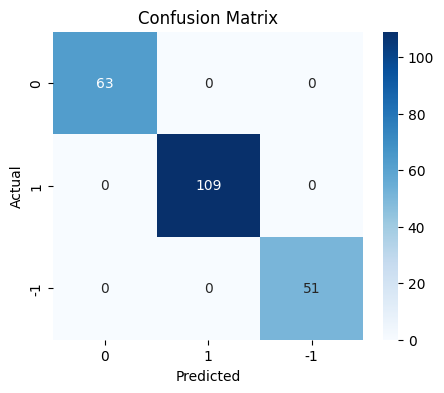

In [ ]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

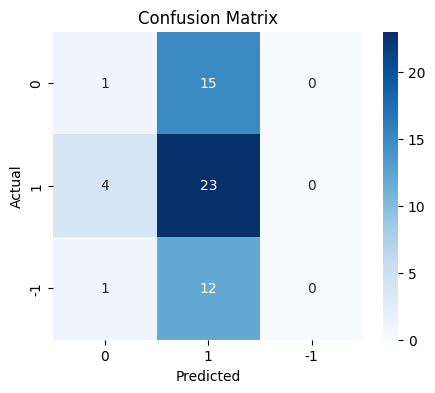

In [ ]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.428571  0.428571   0.269405  0.314007


* After cycling through GradientBoosting, RandomForest and DecisionTree, the RandomForest has the best balanced base model for Word2Vec. It is showing better metrics in Accuracy and Recall, but Precision is lacking.
* The training performance is perfect while the validation is very low which indicates overfitting.

### Base Model - GloVe

In [ ]:
#Building the model

#Uncomment only one of the snippets related to fitting the model to the data

# base_gl = GradientBoostingClassifier(random_state = 42)
# base_gl = RandomForestClassifier(random_state=42, class_weight='balanced')
base_gl = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Fitting on train data
base_gl.fit(X_train_gl, y_train)
# base_gl.fit(X_train_gl, y_train, sample_weight = sample_weights) # for GradientBoosting

DecisionTreeClassifier(class_weight='balanced', random_state=42)

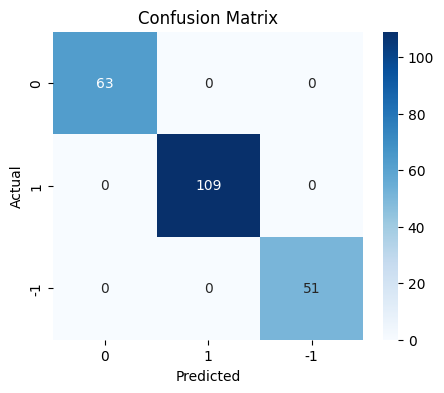

In [ ]:
plot_confusion_matrix(base_gl,X_train_gl,y_train)

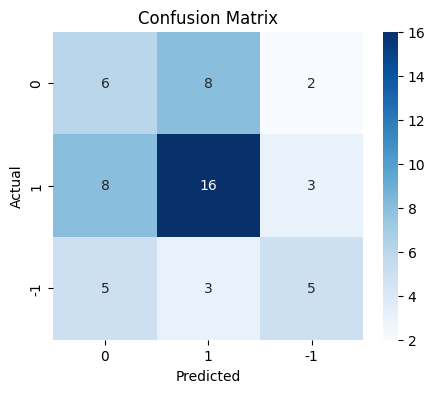

In [ ]:
plot_confusion_matrix(base_gl,X_val_gl,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_gl = model_performance_classification_sklearn(base_gl,X_train_gl,y_train)
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_gl = model_performance_classification_sklearn(base_gl,X_val_gl,y_val)
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.482143  0.482143   0.492011  0.484605


* After cycling through GradientBoosting, RandomForest and DecisionTree, the DecisionTree has the best overall base model for GloVe.
* The training performance is perfect while the validation is very low which indicates overfitting.

### Base Model - Sentence Transformer

In [ ]:
#Building the model

#Uncomment only one of the snippets related to fitting the model to the data

# base_st = GradientBoostingClassifier(random_state = 42)
base_st = RandomForestClassifier(random_state=42, class_weight='balanced')
# base_st = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Fitting on train data
base_st.fit(X_train_st, y_train)
# base_st.fit(X_train_st, y_train, sample_weight = sample_weights) # for GradientBoosting

RandomForestClassifier(class_weight='balanced', random_state=42)

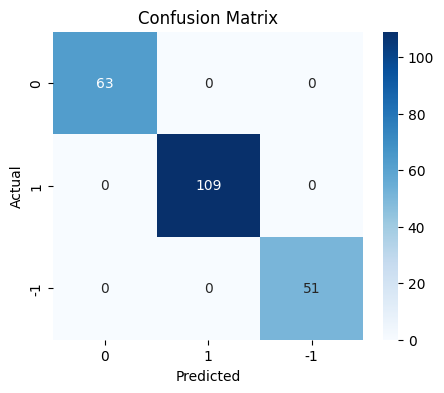

In [ ]:
plot_confusion_matrix(base_st,X_train_st,y_train)

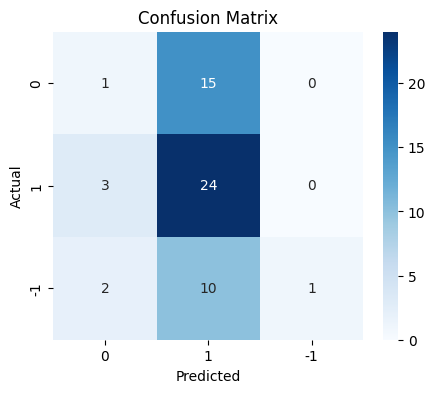

In [ ]:
plot_confusion_matrix(base_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_st = model_performance_classification_sklearn(base_st,X_train_st,y_train)
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_st = model_performance_classification_sklearn(base_st,X_val_st,y_val)
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.464286  0.464286   0.515914  0.363649


* After cycling through GradientBoosting, RandomForest and DecisionTree, the RandomForest has the best balanced base model for Sentence Transformer.
* The training performance is perfect while the validation is very low which indicates overfitting.

### Tuned Model - Word2Vec

In [ ]:
print(X_train_wv.shape)

(223, 300)


In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

# tuned_wv = GradientBoostingClassifier(random_state = 42)
tuned_wv = RandomForestClassifier(random_state=42, class_weight = 'balanced')
# tuned_wv = DecisionTreeClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

Time taken  122.43570232391357


In [ ]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, max_features=0.2,
                       min_samples_split=5, random_state=42)

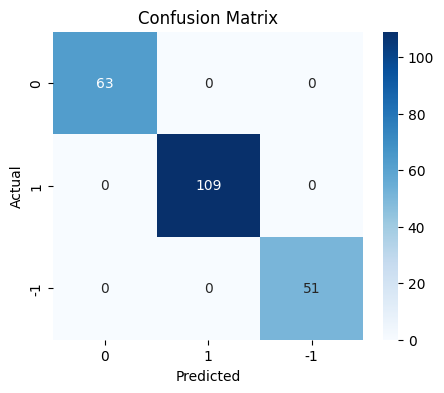

In [ ]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

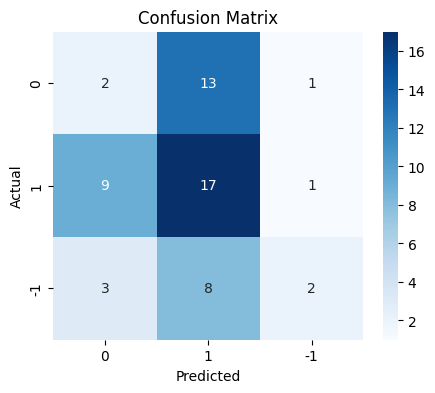

In [ ]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv=model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy  Recall  Precision        F1
0     0.375   0.375   0.372583  0.344915


In [ ]:
print(grid_obj.best_params_)

{'max_depth': 4, 'max_features': 0.2, 'min_samples_split': 5}


* Training is still overfitting but validation has improved.Training time increased significantly when implementing GridSearch

### Tuned Model - GloVe

In [ ]:
start = time.time()

#Uncomment only one of the snippets corrrsponding to the base model trained previously

# tuned_gl = GradientBoostingClassifier(random_state = 42)
#tuned_gl = RandomForestClassifier(random_state=42)
tuned_gl = DecisionTreeClassifier(random_state=42, class_weight = 'balanced')

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

Time taken  2.0927066802978516


In [ ]:
# Fit the best algorithm to the data.
tuned_gl.fit(X_train_gl, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, max_features=0.4,
                       min_samples_split=7, random_state=42)

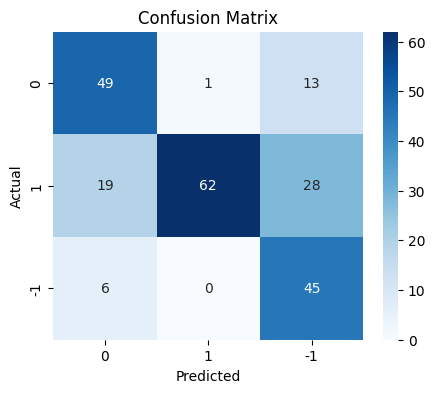

In [ ]:
plot_confusion_matrix(tuned_gl,X_train_gl,y_train)

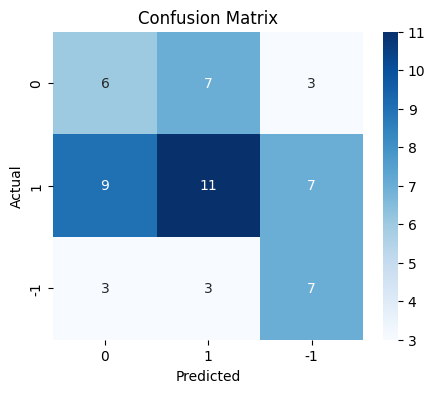

In [ ]:
plot_confusion_matrix(tuned_gl,X_val_gl,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_gl=model_performance_classification_sklearn(tuned_gl,X_train_gl,y_train)
print("Training performance:\n",tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.699552  0.699552   0.787767  0.704712


In [ ]:
#Calculating different metrics on validation data
tuned_val_gl = model_performance_classification_sklearn(tuned_gl,X_val_gl,y_val)
print("Validation performance:\n",tuned_val_gl)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.428571  0.428571   0.443377  0.430156


### Tuned Model - Sentence Transformer

In [ ]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

# tuned_st = GradientBoostingClassifier(random_state = 42)
tuned_st = RandomForestClassifier(random_state=42, class_weight='balanced')
#tuned_st = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

Time taken  128.10826420783997


In [ ]:
# Fit the best algorithm to the data.
tuned_st.fit(X_train_st, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3,
                       min_samples_split=11, random_state=42)

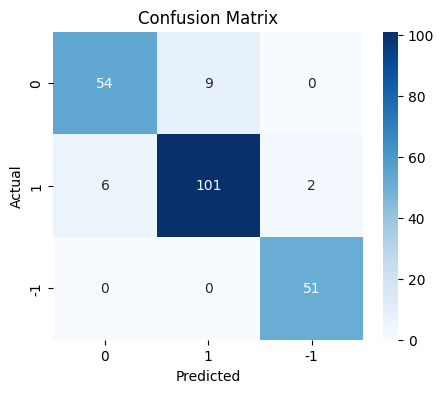

In [ ]:
plot_confusion_matrix(tuned_st,X_train_st,y_train)

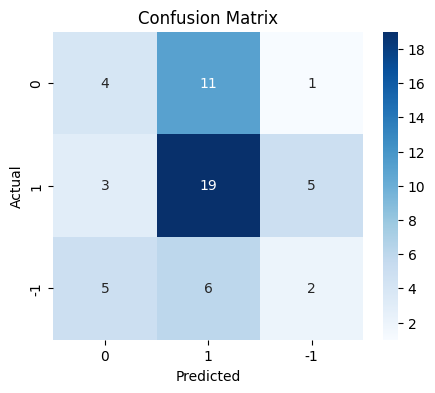

In [ ]:
plot_confusion_matrix(tuned_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_st=model_performance_classification_sklearn(tuned_st,X_train_st,y_train)
print("Training performance:\n",tuned_train_st)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.923767  0.923767   0.923127  0.923207


In [ ]:
#Calculating different metrics on validation data
tuned_val_st = model_performance_classification_sklearn(tuned_st,X_val_st,y_val)
print("Validation performance:\n",tuned_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.446429  0.446429   0.407738  0.416667


### Model Performance Summary and Final Model Selection

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,1.0,1.0,1.0,1.0,0.699552,0.923767
Recall,1.0,1.0,1.0,1.0,0.699552,0.923767
Precision,1.0,1.0,1.0,1.0,0.787767,0.923127
F1,1.0,1.0,1.0,1.0,0.704712,0.923207


In [ ]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.428571,0.482143,0.464286,0.375000,0.428571,0.446429
Recall,0.428571,0.482143,0.464286,0.375000,0.428571,0.446429
Precision,0.269405,0.492011,0.515914,0.372583,0.443377,0.407738
F1,0.314007,0.484605,0.363649,0.344915,0.430156,0.416667


* Going to proceed with the Base GloVe model as it provides the best balance in the validation set.

### Model Performance Check on Test Data

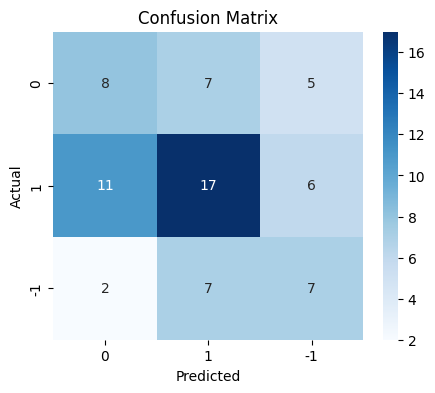

In [ ]:
plot_confusion_matrix(base_gl,X_test_gl,y_test)

In [ ]:
#Calculating different metrics on testing data - Base GloVe
final_model_test = model_performance_classification_sklearn(base_gl,X_test_gl,y_test)
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy    Recall  Precision        F1
0  0.457143  0.457143   0.464092  0.459682


* Based on the different models, the best performing model was the Base GloVe.
* Validation Peformance:
  * Accuracy: 0.4821
  * Recall: 0.4821
  * Precision: 0.4920
  * F1 Score: 0.4846

* Test Performance:
  * Accuracy: 0.457143
  * Recall: 0.457143
  * Precision: 0.464092
  * F1 Score: 0.459682


* Since the model is perfectly fitting on training, that would indicate overfitting but the Validation and Test metrics are close to each other which would indicate that while the performance is generally not good, it has generalized well.

* Explanations:
  *  Need to re-tune and add more model hyperparameters
  * Amount of data is limited
  * Need to add model Regularization techniques

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --no-cache-dir -q


# # Installation for GPU llama-cpp-python
# # uncomment and run the following code in case GPU is being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 212.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 188.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 279.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 273.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 277.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 164.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
stock_news = pd.read_csv("/content/drive/MyDrive/UT_Austin_ML/natural_language_processing/project_stockmarket_sentiment_analysis/stock_news.csv")

In [ ]:
data = stock_news.copy()

#### Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"


model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

llama_model_loader: loaded meta data with 24 key-value pairs and 291 tensors from /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF/snapshots/3a6fbf4a41a1d52e415a4958cde6856d34b2db93/mistral-7b-instruct-v0.2.Q6_K.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.2
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loade

#### Aggregating the data weekly

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

In [ ]:
data_1['News'][0]

' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
import json
import re

def extract_json_data(json_str):
    try:
        # Clean the response by removing markdown artifacts and extra whitespace
        json_str = json_str.replace("```json", "").replace("```", "").strip()

        # Try to locate the JSON object (from the first '{' to the last '}')
        start = json_str.find('{')
        end = json_str.rfind('}')

        if start == -1 or end == -1:
            print(f"Warning: No JSON object found in response: {json_str}")
            return None

        # Extract the valid JSON
        cleaned_json = json_str[start:end+1].strip()

        # Try to load the cleaned JSON
        return json.loads(cleaned_json)

    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return None

##### Defining the response function

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=1000,
      temperature=0.01,
      top_p=0.95,
      top_k=50,
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
news = data_1.loc[0, 'News']

In [ ]:
print(len(news.split(' ')))
news

2611


' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

In [ ]:
#Complete the code to define the prompt for this task
prompt = """

You are an expert data analyst specializing in news content analysis. The goal is to analyze a week's collection of news headlines and identify the top three positive and negative events that are most likely to impact stock prices.

Instructions:
1. Read each news headline carefully.
2. Identify the key entities or subjects mentioned.
3. Identify the events or actions that describe how these entities might affect stock prices.
4. Separate the events into two categories: Positive and Negative.
5. Ensure there are exactly three Positive Events and three Negative Events.
6. Rank these events from most impactful to least impactful within each category.
7. Avoid neutral events or events with no clear impact on stock prices.
8. Return the final output in the JSON format below.

Output Format:
```json
{
  "Positive Events": [
    "Event 1 description",
    "Event 2 description",
    "Event 3 description"
  ],
  "Negative Events": [
    "Event 1 description",
    "Event 2 description",
    "Event 3 description"
  ]
}
"""

In [ ]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)


llama_print_timings:        load time =     534.86 ms
llama_print_timings:      sample time =     188.33 ms /   318 runs   (    0.59 ms per token,  1688.52 tokens per second)
llama_print_timings: prompt eval time =    4827.34 ms /  4021 tokens (    1.20 ms per token,   832.96 tokens per second)
llama_print_timings:        eval time =   12725.63 ms /   317 runs   (   40.14 ms per token,    24.91 tokens per second)
llama_print_timings:       total time =   19114.23 ms /  4338 tokens


```json
{
  "Positive Events": [
    "Roku Inc announces plans to offer premium video channels on a subscription basis through its free streaming service, The Roku Channel.",
    "FDIC Chair Jelena McWilliams expresses no concern over market volatility affecting the U.S banking system.",
    "Chinese central bank announces a fifth reduction in the required reserve ratio (RRR) for banks, freeing up approximately 116.5 billion yuan for new lending."
  ],
  "Negative Events": [
    "Apple cut its quarterly revenue forecast for the first time in over 15 years due to weak iPhone sales in China, representing around 20% of Apple's revenue.",
    "Goldman analyst Rod Hall lowers his price target for Apple from $182 to $140, citing potential risks to the tech giant's 2019 numbers.",
    "Delta Air Lines lowered its fourth-quarter revenue growth forecast to a range of 3% from the previous estimate of 3% to 5%."
  ]
}
```

These events were chosen based on their potential significant impact on st

##### Checking the model output on the weekly data

In [ ]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

  0%|          | 0/18 [00:00<?, ?it/s]Llama.generate: prefix-match hit

llama_print_timings:        load time =     534.86 ms
llama_print_timings:      sample time =     195.69 ms /   318 runs   (    0.62 ms per token,  1624.99 tokens per second)
llama_print_timings: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_print_timings:        eval time =   13077.38 ms /   318 runs   (   41.12 ms per token,    24.32 tokens per second)
llama_print_timings:       total time =   14730.30 ms /   319 tokens
 11%|█         | 2/18 [00:14<01:58,  7.38s/it]Llama.generate: prefix-match hit

llama_print_timings:        load time =     534.86 ms
llama_print_timings:      sample time =     261.81 ms /   288 runs   (    0.91 ms per token,  1100.05 tokens per second)
llama_print_timings: prompt eval time =    2733.27 ms /  2234 tokens (    1.22 ms per token,   817.33 tokens per second)
llama_print_timings:        eval time =   11512.04 ms /   287 runs

CPU times: user 6min 13s, sys: 6.77 s, total: 6min 20s
Wall time: 6min 26s


In [ ]:
data_1["Key Events"].head()

,Key Events
0,"```json\n{\n ""Positive Events"": [\n ""Roku ..."
1,"```json\n{\n ""Positive Events"": [\n ""Sprin..."
2,"```json\n{\n ""Positive Events"": [\n ""Apple..."
3,"```json\n{\n ""Positive Events"": [\n ""IBM's..."
4,"```json\n{\n ""Positive Events"": [\n ""Apple..."


##### Formatting the model output

In [ ]:
print(data_1['Key Events'].head())

0    ```json\n{\n  "Positive Events": [\n    "Roku ...
1    ```json\n{\n  "Positive Events": [\n    "Sprin...
2    ```json\n{\n  "Positive Events": [\n    "Apple...
3    ```json\n{\n  "Positive Events": [\n    "IBM's...
4    ```json\n{\n  "Positive Events": [\n    "Apple...
Name: Key Events, dtype: object


In [ ]:
print(data_1.loc[0, 'Key Events'])

```json
{
  "Positive Events": [
    "Roku Inc announces plans to offer premium video channels on a subscription basis through its free streaming service, The Roku Channel.",
    "FDIC Chair Jelena McWilliams expresses no concern over market volatility affecting the U.S banking system.",
    "Chinese central bank announces a fifth reduction in the required reserve ratio (RRR) for banks, freeing up approximately 116.5 billion yuan for new lending."
  ],
  "Negative Events": [
    "Apple cut its quarterly revenue forecast for the first time in over 15 years due to weak iPhone sales in China, representing around 20% of Apple's revenue.",
    "Goldman analyst Rod Hall lowers his price target for Apple from $182 to $140, citing potential risks to the tech giant's 2019 numbers.",
    "Delta Air Lines lowered its fourth-quarter revenue growth forecast to a range of 3% from the previous estimate of 3% to 5%."
  ]
}
```

These events were chosen based on their potential significant impact on st

In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"```json\n{\n ""Positive Events"": [\n ""Roku ...",{'Positive Events': ['Roku Inc announces plans...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"```json\n{\n ""Positive Events"": [\n ""Sprin...",{'Positive Events': ['Sprint and Samsung plan ...
2,2019-01-20,The U.S. stock market declined on Monday as c...,"```json\n{\n ""Positive Events"": [\n ""Apple...",{'Positive Events': ['Apple CEO Tim Cook annou...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","```json\n{\n ""Positive Events"": [\n ""IBM's...",{'Positive Events': ['IBM's stock price increa...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"```json\n{\n ""Positive Events"": [\n ""Apple...",{'Positive Events': ['Apple reported stronger-...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an...","```json\n{\n ""Positive Events"": [\n ""JPMor...",{'Positive Events': ['JPMorgan suggests Apple ...
6,2019-02-17,"This week, the European Union's second highes...","```json\n{\n ""Positive Events"": [\n ""Apple...",{'Positive Events': ['Apple reported stronger ...
7,2019-02-24,This news article discusses progress towards ...,"```json\n{\n ""Positive Events"": [\n ""Warne...",{'Positive Events': ['Warner Bros adopts gende...
8,2019-03-03,The Dow Jones Industrial Average and other ma...,"```json\n{\n ""Positive Events"": [\n ""Presi...",{'Positive Events': ['President Trump announce...
9,2019-03-10,"Spotify, the world's largest paid music strea...","```json\n{\n ""Positive Events"": [\n ""Spoti...",{'Positive Events': ['Spotify reported over 1 ...


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,Positive Events,Negative Events
0,[Roku Inc announces plans to offer premium vid...,[Apple cut its quarterly revenue forecast for ...
1,[Sprint and Samsung plan to release 5G smartph...,"[Geely, China's most successful carmaker, fore..."
2,[Apple CEO Tim Cook announced internal staffin...,[The U.S. stock market declined on Monday as c...
3,[IBM's stock price increased after hours due t...,"[The Swiss National Bank (SNB) governor, Andre..."
4,[Apple reported stronger-than-expected earning...,[Caterpillar reported lower-than-expected four...


In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
final_output.columns = ['Week End Date', 'News', 'Week Positive Events', 'Week Negative Events']

final_output.head()

,Week End Date,News,Week Positive Events,Week Negative Events
0,2019-01-06,The tech sector experienced a significant dec...,[Roku Inc announces plans to offer premium vid...,[Apple cut its quarterly revenue forecast for ...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,[Sprint and Samsung plan to release 5G smartph...,"[Geely, China's most successful carmaker, fore..."
2,2019-01-20,The U.S. stock market declined on Monday as c...,[Apple CEO Tim Cook announced internal staffin...,[The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",[IBM's stock price increased after hours due t...,"[The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,[Apple reported stronger-than-expected earning...,[Caterpillar reported lower-than-expected four...


## **Conclusions and Recommendations**

`Conclusion/ Summary`
* The model using `mistral-7b-instruct-v0.2.Q6_K.gguf` effectively analyzes weekly news headlines to extract and rank stock relevant events. It categorizes them as either positive or negative based on their expected impact on stock performance.
* Initial problems such as incomplete JSON outputs found in the first data point were traced back to insufficient prompt structures showing a strong significance and need for properly worded prompts.
* The current version of the prompt returns exactly 3 `Positive Events` and 3 `Negative Events` in a defined JSON format.

` Recommendations`
* Ensure that any additional versions of the prompts are Clear and Structured
* Many of the issues with validation due to prompting could have been prevented or significantly reduced if automated checks for validation was implemented. - This would be something I would modify on future projects
* The model took a long time to run with max_tokens set to 1000 to ensure high volume news weeks would hopefully be captured. - I would recommend implementing a way to split those high volume news weeks into smaller logical batches to avoid overloading the model and reduce the changes of response cutoff.
* If working on the prompt, I would encourage exploring prompt templates for other uses cases.

Overall, the model responses were exactly as expected and stated after some prompt engineering of course! A user of this model would be able to identify whether a company's news could potentially effect their stocks both positive and negatively for the week. This would assist them in determining what they might want to do with that company stock.




<font size=6 color='blue'>Power Ahead</font>
___